t# Document length distributions

Plots per-document token-length distributions produced by `attn_bench/data_processing/dataset_doc_stats.py`.

On the cluster:
```bash
python attn_bench/data_processing/dataset_doc_stats.py
```
which writes one `<dataset_name>.npy` per dataset under `/users/$USER/store/datasets/analysis/doc-lengths`.
Transfer those `.npy` files locally and point `DATA_DIR` below at them.

In [46]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Local dir holding the transferred <dataset_name>.npy files
DATA_DIR = Path("../results/datasets/analysis/doc-lengths")

# Pretty names for the legend / titles (falls back to the file stem if not listed)
DISPLAY_NAMES = {
    "fineweb-edu-dedup-160B-datatrove": "fineweb-edu-full",
    "fineweb-edu-dedup-160B-datatrove_0.25": "fineweb-edu-0.25",
    "gutenberg_rep_1_256": "gutenberg",
}
def disp(name):
    return DISPLAY_NAMES.get(name, name)

PERCENTILES = [1, 5, 25, 50, 75, 90, 95, 99]

datasets = {p.stem: np.load(p) for p in sorted(DATA_DIR.glob("*.npy"))}
print("loaded:", list(datasets))

loaded: ['fineweb-edu-dedup-160B-datatrove', 'fineweb-edu-dedup-160B-datatrove_0.25', 'gutenberg_rep_1_256']


In [47]:
def print_stats(name, lengths):
    pct = np.percentile(lengths, PERCENTILES)
    print(f"### {disp(name)} ###")
    print(f"  documents:    {len(lengths):,}")
    print(f"  total tokens: {int(lengths.sum()):,}")
    print(f"  mean:         {lengths.mean():,.1f}")
    print(f"  std:          {lengths.std():,.1f}")
    print(f"  min / max:    {lengths.min():,} / {lengths.max():,}")
    print("  percentiles:  " + "  ".join(f"p{p}={int(v):,}" for p, v in zip(PERCENTILES, pct)))

for name, lengths in datasets.items():
    print_stats(name, lengths)

### fineweb-edu-full ###
  documents:    161,370,257
  total tokens: 160,159,943,902
  mean:         992.5
  std:          1,873.0
  min / max:    29 / 266,969
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,070  p90=1,868  p95=2,824  p99=7,358
### fineweb-edu-0.25 ###
  documents:    40,342,565
  total tokens: 40,038,865,413
  mean:         992.5
  std:          1,873.7
  min / max:    34 / 196,868
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,071  p90=1,868  p95=2,823  p99=7,348
### gutenberg ###
  documents:    337,260
  total tokens: 2,762,833,920
  mean:         8,192.0
  std:          0.0
  min / max:    8,192 / 8,192
  percentiles:  p1=8,192  p5=8,192  p25=8,192  p50=8,192  p75=8,192  p90=8,192  p95=8,192  p99=8,192


## Per-dataset histograms

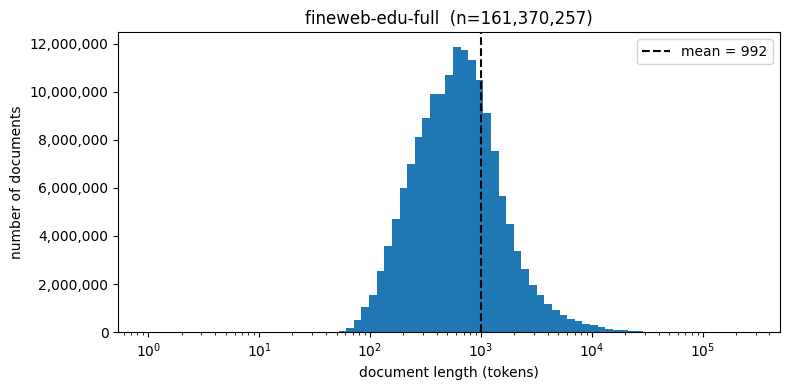

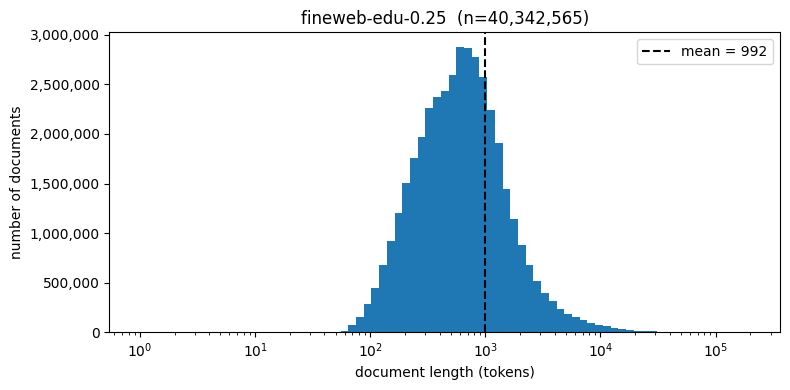

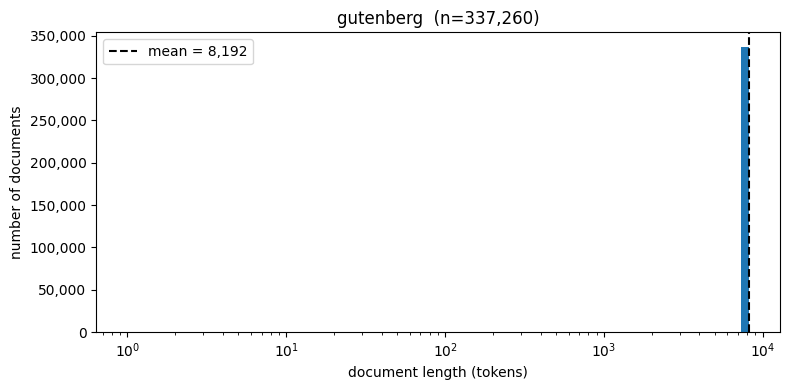

In [48]:
from matplotlib.ticker import FuncFormatter

thousands = FuncFormatter(lambda x, _: f"{int(x):,}")

for name, lengths in datasets.items():
    bins = np.logspace(0, np.log10(lengths.max() + 1), 80)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=bins)
    ax.axvline(lengths.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean = {lengths.mean():,.0f}")
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(thousands)
    ax.set_xlabel("document length (tokens)")
    ax.set_ylabel("number of documents")
    ax.set_title(f"{disp(name)}  (n={len(lengths):,})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Overlaid

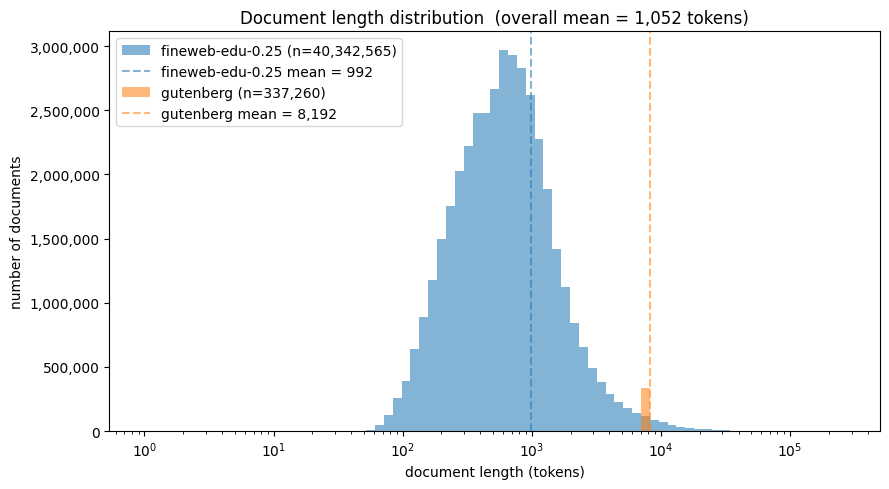

In [49]:
global_max = max(l.max() for l in datasets.values())
bins = np.logspace(0, np.log10(global_max + 1), 80)

fig, ax = plt.subplots(figsize=(9, 5))
plotted = []   # every dataset actually drawn, pooled below for the overall mean
for name, lengths in datasets.items():
    if name == "fineweb-edu-dedup-160B-datatrove":
        continue
    plotted.append(lengths)
    _, _, patches = ax.hist(lengths, bins=bins, alpha=0.55, label=f"{disp(name)} (n={len(lengths):,})")
    color = patches[0].get_facecolor()
    ax.axvline(lengths.mean(), color=color, linestyle="--", linewidth=1.5,
               label=f"{disp(name)} mean = {lengths.mean():,.0f}")

# Pooled mean over all plotted documents (dominated by fineweb since it has far more docs).
overall_mean = np.concatenate(plotted).mean()
ax.set_xscale("log")
ax.yaxis.set_major_formatter(thousands)
ax.set_xlabel("document length (tokens)")
ax.set_ylabel("number of documents")
ax.set_title(f"Document length distribution  (overall mean = {overall_mean:,.0f} tokens)")
ax.legend()
plt.tight_layout()
plt.show()

## Token budget by length

For length-informed data selection: how many *tokens* (not documents) sit in each
document-length range. `range_budget(lengths, lo, hi)` is the primitive — tokens in docs with
length in `[lo, hi)` (`hi=None` means "≥ lo"). The chart shows the token budget per 1k bin
(bars) together with the reverse-cumulative "tokens in docs ≥ x" curve, both on one log y-axis
in billions: at each x the curve is the budget you keep by taking every document at least x long,
starting at the total and dropping as you raise the threshold. The log scale keeps the small tail
bins readable next to the huge short-doc bins — but on a log axis bar heights are no longer
visually proportional, so read exact budgets off the curve or `range_budget`.

In [22]:
def range_budget(lengths, lo=0, hi=None):
    # Tokens (and docs) in documents with length in [lo, hi). hi=None -> no upper bound, i.e.
    # the ">= lo" selection budget. This is the primitive for length-informed data selection:
    # how many training tokens a given length range gives you.
    m = lengths >= lo
    if hi is not None:
        m = m & (lengths < hi)
    tokens = lengths[m].astype(np.float64).sum()
    tot = lengths.astype(np.float64).sum()
    docs = int(m.sum())
    hi_s = "inf" if hi is None else f"{hi:,}"
    print(f"[{lo:,}, {hi_s}): {docs:,} docs, {tokens/1e9:.2f}B tokens ({100*tokens/tot:.1f}% of {tot/1e9:.1f}B)")
    return {"docs": docs, "tokens": float(tokens), "pct": 100 * tokens / tot}


# Examples on fineweb-edu-0.25 -- edit the range for whatever subset you are considering.
fw = datasets["fineweb-edu-dedup-160B-datatrove"]
range_budget(fw, 3650)          # docs at least one full training sequence long
range_budget(fw, 0, 3650);          # a length band

[3,650, inf): 5,294,858 docs, 40.03B tokens (25.0% of 160.2B)
[0, 3,650): 156,075,399 docs, 120.13B tokens (75.0% of 160.2B)


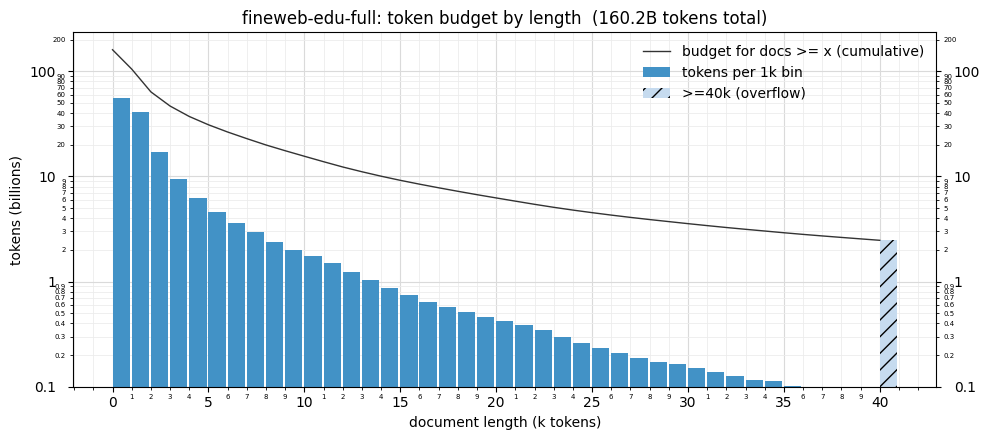

In [43]:
# Token budget per 1k document-length bin (bars) + reverse-cumulative "tokens in docs >= x"
# curve. Both are token counts in billions, so they share ONE y-axis: the curve starts at the
# total (towering over the bars) and drops as the length threshold rises -- read the budget for
# any cutoff straight off it. Bars are capped at MAX_TOK with one overflow bar pooling everything
# longer; the curve includes that overflow, so at x=0 it equals the total. The y-axis is log so
# the small tail bins (e.g. 7-9k) stay readable next to the huge first bin -- but note that on a
# log scale bar heights are no longer visually proportional, so read exact budgets off the curve.
from matplotlib.ticker import FuncFormatter, MultipleLocator

MAX_TOK = 40000
MAX_K = MAX_TOK // 1000
edges = np.arange(0, MAX_TOK + 1000, 1000)   # 0, 1k, ..., 32k
left_k = edges[:-1] / 1000                    # bar left edges, in k tokens

for name, lengths in datasets.items():
    if name == "fineweb-edu-dedup-160B-datatrove_0.25":   # plot only the full 160B set here
        continue
    if name == "gutenberg_rep_1_256":                # all docs are exactly 8192 -> single bar, pointless
        continue
    w = lengths.astype(np.float64)
    tot = w.sum()
    tok = np.histogram(lengths, bins=edges, weights=w)[0]   # tokens per 1k bin, capped
    overflow = w[lengths >= MAX_TOK].sum()
    # tokens in docs >= x, in billions: starts at the total and drops as the threshold rises.
    rev = (tot - np.concatenate([[0], np.cumsum(tok)])) / 1e9   # one value per edge

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.set_axisbelow(True)
    ax.grid(color="#dadada", linewidth=0.8)
    ax.grid(which="minor", color="#ececec", linewidth=0.6)   # denser minor grid helps read the log tail
    ax.bar(left_k, tok / 1e9, width=0.9, align="edge", color="#4292C6", label="tokens per 1k bin")
    if overflow > 0:
        ax.bar(MAX_TOK / 1000, overflow / 1e9, width=0.9, align="edge",
               color="#c6dbef", hatch="//", label=f">={MAX_TOK//1000}k (overflow)")
    ax.plot(edges / 1000, rev, color="#333333", linewidth=1, label="budget for docs >= x (cumulative)")
    ax.set_xlabel("document length (k tokens)")
    ax.set_ylabel("tokens (billions)")
    ax.set_yscale("log")
    ax.set_ylim(bottom=0.1)   # floor below the smallest capped bin so every bar is visible

    # Powers of ten as plain numbers (%g so 0.1 does not round to "0"); label every minor tick too
    # (0.2-0.9, 2-9, 20-90) in a tiny font so each decade has full intra-decade reference marks.
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    # Mirror the same scale on the right edge so values are easy to read on both sides.
    ax.tick_params(axis="y", which="both", right=True, labelright=True)
    ax.tick_params(axis="y", which="minor", labelsize=5)
    # Push the big power-of-ten labels further out so they clear the tiny minor labels next to them.
    ax.tick_params(axis="y", which="major", pad=9)

    # x minor ticks every 1k, labelled with just the last digit (17 -> "7", 19 -> "9") so the bars
    # line up with readable marks; the 5-multiples stay as major ticks. Blank anything outside the
    # real 0..MAX_K range so no stray labels appear past the edges.
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_minor_formatter(
        FuncFormatter(lambda v, _: f"{int(round(v)) % 10}" if 0 <= v <= MAX_K else ""))
    ax.tick_params(axis="x", which="minor", labelsize=5)

    ax.legend(loc="upper right", frameon=False)
    ax.set_title(f"{disp(name)}: token budget by length  ({tot/1e9:,.1f}B tokens total)")
    plt.tight_layout()
    plt.show()

In [45]:
# Candidate cap range for long-fineweb extraction: docs 3-4 training sequence lengths long.
SEQ_LEN = 8192
LO, HI = 3 * SEQ_LEN, 4 * SEQ_LEN

for name in ("fineweb-edu-dedup-160B-datatrove_0.25", "fineweb-edu-dedup-160B-datatrove"):
    range_budget(datasets[name], LO, HI)

[24,576, 32,768): 13,125 docs, 0.37B tokens (0.9% of 40.0B)
[24,576, 32,768): 52,153 docs, 1.46B tokens (0.9% of 160.2B)


## Packed chunk-length distribution (training-time chunking)

Plots the packed-segment ("chunk") length distribution produced by
`attn_bench/data_processing/packed_chunk_stats.py`: for one full epoch, documents are
concatenated and chopped into fixed `seq_len`-token training windows, so a chunk ends at
whichever comes first -- the document's end, or the sample window's end. Unlike the raw
document lengths above, this is what the model actually attends to per sample.

On the cluster (see `attn_bench/submissions/packed_chunk_stats.slurm`), which writes one
`<dataset_name>_chunk_len_hist.npy` (+ `_run_metadata.json`) per dataset under
`/users/$USER/store/datasets/packed_chunk_lengths/`. Transfer those files locally into
`attn_bench/results/datasets/packed_chunk_lengths/` and point `CHUNK_DATA_DIR` below at them.

In [50]:
import json

CHUNK_DATA_DIR = Path("../results/datasets/packed_chunk_lengths")

def chunk_hist_stats(hist):
    lengths = np.arange(1, len(hist) + 1)
    total = int(hist.sum())
    mean = float((lengths * hist).sum() / total)
    std = float(np.sqrt((((lengths - mean) ** 2) * hist).sum() / total))
    cum = np.cumsum(hist)
    nonzero = np.flatnonzero(hist)
    pct = {p: int(lengths[np.searchsorted(cum, p / 100 * total)]) for p in PERCENTILES}
    return {"chunks": total, "mean": mean, "std": std,
            "min": int(lengths[nonzero[0]]), "max": int(lengths[nonzero[-1]]), "percentiles": pct}

def print_chunk_stats(name, stats, job_id=None):
    print(f"### {disp(name)} ###" + (f"  (job {job_id})" if job_id else ""))
    print(f"  chunks:       {stats['chunks']:,}")
    print(f"  mean:         {stats['mean']:,.1f}")
    print(f"  std:          {stats['std']:,.1f}")
    print(f"  min / max:    {stats['min']:,} / {stats['max']:,}")
    print("  percentiles:  " + "  ".join(f"p{p}={v:,}" for p, v in stats["percentiles"].items()))

chunk_hists = {}
chunk_stats = {}
for p in sorted(CHUNK_DATA_DIR.glob("*_chunk_len_hist.npy")):
    name = p.stem.removesuffix("_chunk_len_hist")
    hist = np.load(p)
    chunk_hists[name] = hist
    stats = chunk_hist_stats(hist)
    chunk_stats[name] = stats
    meta_path = CHUNK_DATA_DIR / f"{name}_run_metadata.json"
    job_id = json.loads(meta_path.read_text())["job_id"] if meta_path.exists() else None
    print_chunk_stats(name, stats, job_id)

### fineweb-edu-0.25 ###  (job 2765239)
  chunks:       45,224,954
  mean:         885.3
  std:          1,096.5
  min / max:    1 / 8,192
  percentiles:  p1=47  p5=123  p25=297  p50=567  p75=1,019  p90=1,799  p95=2,716  p99=6,503
### gutenberg ###  (job 2765239)
  chunks:       337,251
  mean:         8,192.0
  std:          0.0
  min / max:    8,192 / 8,192
  percentiles:  p1=8,192  p5=8,192  p25=8,192  p50=8,192  p75=8,192  p90=8,192  p95=8,192  p99=8,192


In [ ]:
for name, hist in chunk_hists.items():
    seq_len = len(hist)
    lengths = np.arange(1, seq_len + 1)
    bins = np.logspace(0, np.log10(seq_len + 1), 80)  # +1: avoid the max edge landing just
                                                        # below seq_len from log10/pow roundoff
                                                        # and silently dropping every seq_len-length chunk
    stats = chunk_stats[name]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=bins, weights=hist)
    ax.axvline(stats["mean"], color="black", linestyle="--", linewidth=1.5,
               label=f"mean = {stats['mean']:,.0f}")
    ax.set_xscale("log")  # log axis already gives intra-decade (2,3,...,9) minor ticks
    ax.yaxis.set_major_formatter(thousands)
    ax.set_axisbelow(True)
    ax.grid(which="major", color="#dadada", linewidth=0.8)
    ax.grid(which="minor", color="#ececec", linewidth=0.6)
    ax.set_xlabel("chunk length (tokens)")
    ax.set_ylabel("number of chunks")
    ax.set_title(f"{disp(name)}: packed chunk length  (n={stats['chunks']:,}, seq_len={seq_len:,})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Doc length vs packed chunk length (same dataset)

Overlays each dataset's raw document lengths against its packed chunk lengths, so the effect
of packing is visible directly: docs longer than `seq_len` get cut into several
`seq_len`-sized chunks (mass appears at/near `seq_len` that wasn't there before), and any doc
that happens to straddle a sample boundary gets split into two shorter chunks -- occasionally
into one very short sliver (e.g. FineWeb has ~9,900 length-1 chunks out of 45.2M, ~0.02%).
Most short docs are unaffected (whole doc = one chunk).

Plotted as **fraction of total per bin**, not `density=True`: with log-spaced bins,
`density=True` divides by the (linear) bin width, and the first bin near x=1 is ~70x narrower
than bins further out -- so even that negligible sliver of length-1 chunks would get blown up
into the tallest bar in the plot. Weighting by 1/N avoids that distortion entirely.

plotting: ['fineweb-edu-dedup-160B-datatrove_0.25', 'gutenberg_rep_1_256']


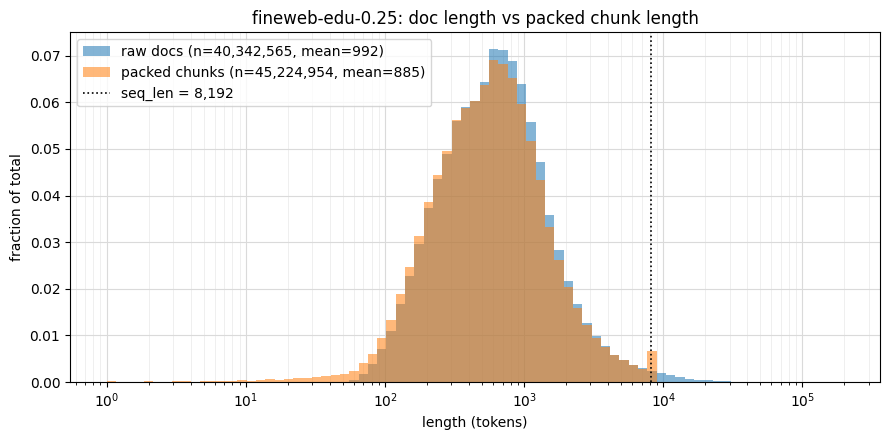

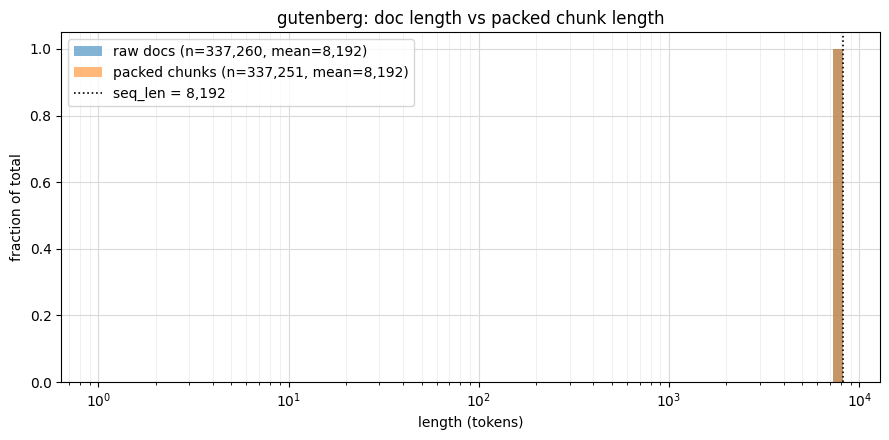

In [54]:
common = sorted(set(datasets) & set(chunk_hists))
print("plotting:", common)

for name in common:
    doc_lengths = datasets[name]
    hist = chunk_hists[name]
    seq_len = len(hist)
    chunk_lengths = np.arange(1, seq_len + 1)

    max_len = max(doc_lengths.max(), seq_len)
    bins = np.logspace(0, np.log10(max_len + 1), 80)  # +1: avoid dropping max-length values
                                                        # (log10/pow roundoff can put the last
                                                        # edge just below max_len)

    # NOTE: deliberately NOT density=True. With log-spaced bins, density=True divides each
    # bin's count by its (linear) bin *width* -- and the first log-bin near x=1 is ~70x
    # narrower than bins further out, so even a handful of very-short chunks (sample-window
    # cuts landing right next to a doc boundary -- real, but <0.03% of chunks) get blown up
    # into the tallest bar in the plot. Weighting by 1/N instead gives "fraction of total per
    # (already log-spaced, so already fair) bin", which is what we actually want to compare.
    ax_doc_weights = np.full(len(doc_lengths), 1 / len(doc_lengths))
    chunk_weights = hist / hist.sum()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(doc_lengths, bins=bins, weights=ax_doc_weights, alpha=0.55,
            label=f"raw docs (n={len(doc_lengths):,}, mean={doc_lengths.mean():,.0f})")
    ax.hist(chunk_lengths, bins=bins, weights=chunk_weights, alpha=0.55,
            label=f"packed chunks (n={int(hist.sum()):,}, mean={chunk_stats[name]['mean']:,.0f})")
    ax.axvline(seq_len, color="black", linestyle=":", linewidth=1.2, label=f"seq_len = {seq_len:,}")
    ax.set_xscale("log")
    ax.set_axisbelow(True)
    ax.grid(which="major", color="#dadada", linewidth=0.8)
    ax.grid(which="minor", color="#ececec", linewidth=0.6)
    ax.set_xlabel("length (tokens)")
    ax.set_ylabel("fraction of total")
    ax.set_title(f"{disp(name)}: doc length vs packed chunk length")
    ax.legend()
    plt.tight_layout()
    plt.show()